In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({'figure.figsize': (12, 6),'figure.dpi':120})

In [2]:
products = pd.read_csv("../data/raw/products.csv")
orders = pd.read_csv("../data/raw/orders.csv")
order_items = pd.read_csv("../data/raw/order_items.csv")
order_item_refunds = pd.read_csv("../data/raw/order_item_refunds.csv")
website_pageviews = pd.read_csv("../data/raw/website_pageviews.csv")
website_sessions = pd.read_csv("../data/raw/website_sessions.csv")

In [3]:
datasets = {
    "products"          : products,
    "orders"            : orders,
    "order_items"       : order_items,
    "order_item_refunds": order_item_refunds,
    "website_pageviews" : website_pageviews,
    "website_sessions"  : website_sessions
}

In [ ]:
summary_before = []
for name, df in datasets.items():
    summary_before.append({
        "table_name" : name,
        "rows"        : df.shape[0],
        "columns"     : df.shape[1],
        "missing_Value" : df.isnull().sum().sum(),
        "duplicate"     : df.duplicated().sum(), 
    })
print("-" * 60)
print("Summary_Before") 
print("-" * 60)
summary_before_df = pd.DataFrame(summary_before)
display(summary_before_df)

------------------------------------------------------------
Summary_Before


,table_name,rows,columns,missing_Value,duplicate
0,products,4,3,0,0
1,orders,32313,8,0,0
2,order_items,40025,7,0,0
3,order_item_refunds,1731,5,0,0
4,website_pageviews,1188124,4,0,0
5,website_sessions,472871,9,289901,0


In [17]:
for name,df in datasets.items():
    print("-" * 60)
    print(f"{name}".upper())
    print("-" * 60)
    display(df.head())
    print("\n")

------------------------------------------------------------
PRODUCTS
------------------------------------------------------------


,product_id,created_at,product_name,year,month,day,hour,day_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy,2012,3,19,8,Monday
1,2,2013-01-06 13:00:00,The Forever Love Bear,2013,1,6,13,Sunday
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda,2013,12,12,9,Thursday
3,4,2014-02-05 10:00:00,The Hudson River Mini bear,2014,2,5,10,Wednesday




------------------------------------------------------------
ORDERS
------------------------------------------------------------


,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,year,month,day,hour,day_name
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012,3,19,10,Monday
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012,3,19,19,Monday
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012,3,20,6,Tuesday
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012,3,20,9,Tuesday
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012,3,20,11,Tuesday




------------------------------------------------------------
ORDER_ITEMS
------------------------------------------------------------


...

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd,year,month,day,hour,day_name
0,1,2012-04-06 11:32:43,57,57,49.99,2012,4,6,11,Friday
1,2,2012-04-13 01:09:43,74,74,49.99,2012,4,13,1,Friday
2,3,2012-04-15 07:03:48,71,71,49.99,2012,4,15,7,Sunday
3,4,2012-04-17 20:00:37,118,118,49.99,2012,4,17,20,Tuesday
4,5,2012-04-22 20:53:49,116,116,49.99,2012,4,22,20,Sunday




------------------------------------------------------------
WEBSITE_PAGEVIEWS
------------------------------------------------------------


,website_pageview_id,created_at,website_session_id,pageview_url,year,month,day,hour,day_name
0,1,2012-03-19 08:04:16,1,/home,2012,3,19,8,Monday
1,2,2012-03-19 08:16:49,2,/home,2012,3,19,8,Monday
2,3,2012-03-19 08:26:55,3,/home,2012,3,19,8,Monday
3,4,2012-03-19 08:37:33,4,/home,2012,3,19,8,Monday
4,5,2012-03-19 09:00:55,5,/home,2012,3,19,9,Monday




------------------------------------------------------------
WEBSITE_SESSIONS
------------------------------------------------------------


,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,year,month,day,hour,day_name
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012,3,19,8,Monday
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,3,19,8,Monday
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,3,19,8,Monday
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,3,19,8,Monday
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012,3,19,9,Monday


In [14]:
datetime_tables = [
    orders,
    order_items,
    order_item_refunds,
    products,
    website_sessions,
    website_pageviews
]

for df in datetime_tables:
    df["created_at"] = pd.to_datetime(
        df["created_at"],
        errors="coerce"
    )

In [16]:
for name, df in datasets.items():
    df["year"] = df["created_at"].dt.year
    df["month"] = df["created_at"].dt.month
    df["day"] = df["created_at"].dt.day
    df["hour"] = df["created_at"].dt.hour
    df["day_name"] = df["created_at"].dt.day_name()

In [18]:
website_sessions["utm_source"] = (
    website_sessions["utm_source"]
    .fillna("direct")
)

website_sessions["utm_campaign"] = (
    website_sessions["utm_campaign"]
    .fillna("unknown_campaign")
)

website_sessions["utm_content"] = (
    website_sessions["utm_content"]
    .fillna("unknown_content")
)

website_sessions["http_referer"] = (
    website_sessions["http_referer"]
    .fillna("direct_traffic")
)

In [19]:
numeric_checks = {
    "orders": [
        "price_usd",
        "cogs_usd",
        "items_purchased"
    ],

    "order_items": [
        "price_usd",
        "cogs_usd"
    ],

    "order_item_refunds": [
        "refund_amount_usd"
    ]
}

for table_name, columns in numeric_checks.items():
    df = datasets[table_name]
    print("=" * 60)
    print(f"NEGATIVE VALUE CHECK: {table_name.upper()}")
    print("=" * 60)
    for col in columns:
        negative_count = (df[col] < 0).sum()
        print(f"{col}: {negative_count}")
    

NEGATIVE VALUE CHECK: ORDERS
price_usd: 0
cogs_usd: 0
items_purchased: 0
NEGATIVE VALUE CHECK: ORDER_ITEMS
price_usd: 0
cogs_usd: 0
NEGATIVE VALUE CHECK: ORDER_ITEM_REFUNDS
refund_amount_usd: 0


In [20]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return outliers


outlier_columns = {
    "orders": ["price_usd", "cogs_usd"],
    "order_items": ["price_usd", "cogs_usd"],
    "order_item_refunds": ["refund_amount_usd"]
}

for table_name, columns in outlier_columns.items():

    df = datasets[table_name]

    print("=" * 60)
    print(f"OUTLIER ANALYSIS: {table_name.upper()}")
    print("=" * 60)

    for col in columns:
        outliers = detect_outliers(df, col)
        print(f"{col} -> Outliers: {len(outliers)}")

OUTLIER ANALYSIS: ORDERS
price_usd -> Outliers: 8246
cogs_usd -> Outliers: 9623
OUTLIER ANALYSIS: ORDER_ITEMS
price_usd -> Outliers: 15799
cogs_usd -> Outliers: 15799
OUTLIER ANALYSIS: ORDER_ITEM_REFUNDS
refund_amount_usd -> Outliers: 494


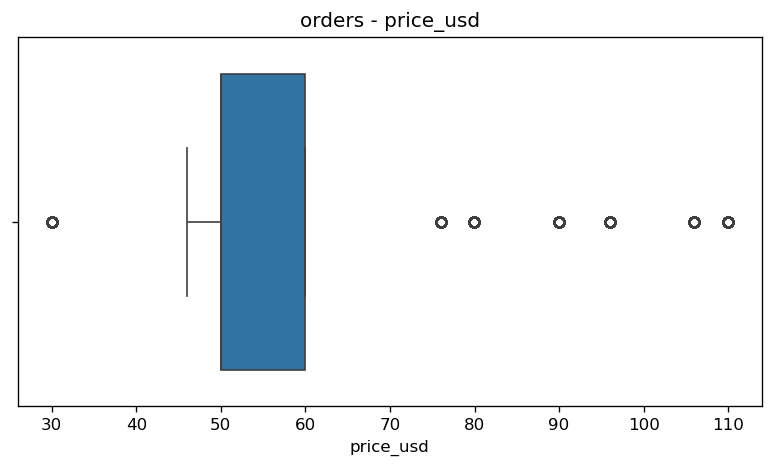

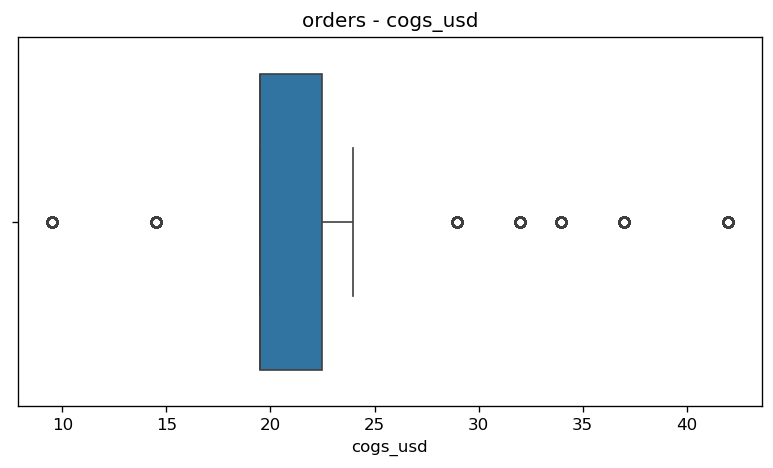

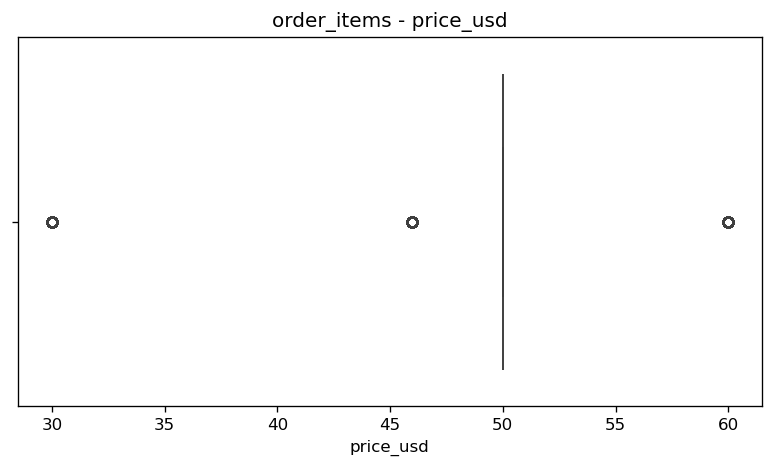

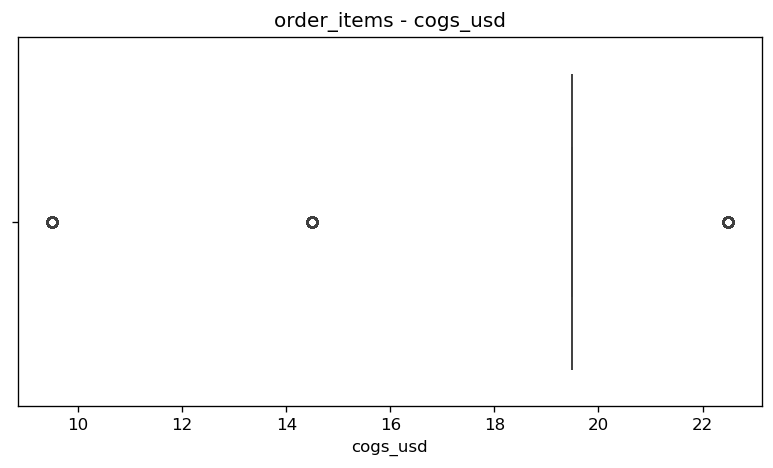

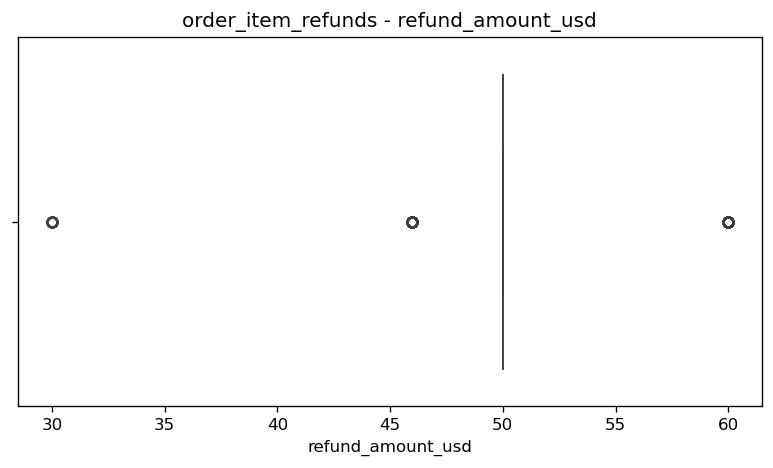

In [ ]:

for table_name, columns in outlier_columns.items():
    df = datasets[table_name]
    for col in columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col])
        plt.title(f"{table_name} - {col}")
        plt.show()

In [23]:

summary_after = []
for name, df in datasets.items():
    summary_after.append({
        "table_name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": df.isnull().sum().sum(),
        "duplicate_rows": df.duplicated().sum()
    })
summary_after_df = pd.DataFrame(summary_after)
print("=" * 60)
print("AFTER CLEANING")
print("=" * 60)

display(summary_after_df)

AFTER CLEANING


,table_name,rows,columns,missing_values,duplicate_rows
0,products,4,8,0,0
1,orders,32313,13,0,0
2,order_items,40025,12,0,0
3,order_item_refunds,1731,10,0,0
4,website_pageviews,1188124,9,0,0
5,website_sessions,472871,14,0,0


In [24]:
orders.to_csv(
    "../data/cleaned/cleaned_orders.csv",
    index=False
)

order_items.to_csv(
    "../data/cleaned/cleaned_order_items.csv",
    index=False
)

order_item_refunds.to_csv(
    "../data/cleaned/cleaned_order_item_refunds.csv",
    index=False
)

products.to_csv(
    "../data/cleaned/cleaned_products.csv",
    index=False
)

website_sessions.to_csv(
    "../data/cleaned/cleaned_website_sessions.csv",
    index=False
)

website_pageviews.to_csv(
    "../data/cleaned/cleaned_website_pageviews.csv",
    index=False
)